## Recommendation System - Part I

### Product popularity based recommendation system targeted at new customers

Popularity based are a great strategy to target the new customers with the most popular products sold on a business's website and is very useful to cold start a recommendation engine.

## Amazon product review dataset

Source: https://www.kaggle.com/skillsmuggler/amazon-ratings

#### Importing libraries

In [8]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install scikit-learn

   ---------------------------------------- 0.0/8.7 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.7 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.7 MB 2.4 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.7 MB 2.5 MB/s eta 0:00:03
   ------ --------------------------------- 1.3/8.7 MB 2.5 MB/s eta 0:00:03
   --------- ------------------------------ 2.1/8.7 MB 2.3 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.7 MB 2.3 MB/s eta 0:00:03
   -------------- ------------------------- 3.1/8.7 MB 2.4 MB/s eta 0:00:03
   ---------------- ----------------------- 3.7/8.7 MB 2.3 MB/s eta 0:00:03
   ------------------ --------------------- 3.9/8.7 MB 2.2 MB/s eta 0:00:03
   -------------------- ------------------- 4.5/8.7 MB 2.3 MB/s eta 0:00:02
   ---------------------- ----------------- 5.0/8.7 MB 2.3 MB/s eta 0:00:02
   ------------------------- -------------- 5.5/8.7 MB 2.3 MB/s eta 0:00:02
   -----------------------

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# %matplotlib inline
plt.style.use("ggplot")

import sklearn
from sklearn.decomposition import TruncatedSVD

#### Loading the dataset

In [10]:
!pip install kaggle
!mkdir -p ~/.kaggle
upload_file_path = '/content/kaggle.json'
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached pathspec-0.12.1-py3-none-any.whl.metadata (21 kB)
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   --------------- ------------------------ 0.5/1.4 MB 2.5 MB/s eta 0:00:01
   ----------------------- ---------------- 0.8/1.4 MB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 1.4/1.4 MB 2.2 MB/s  0:00:00
   ---------------------------------------- 0.0/9.8 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.8 MB 2.6 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/9.8 MB 2.6 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.8 MB 2.2 MB/s eta 0:00:04
   ------- -------------------------------- 1.8/9.8 MB 2.3 MB/s eta 0:00:04
   --------- ------------------------------ 2.4/9.8 MB 2.3 MB/s eta 0:00:04
   ----------- ---------------------------- 2.9/9.8 MB 2.3 MB/s

The syntax of the command is incorrect.
'cp' is not recognized as an internal or external command,
operable program or batch file.
'chmod' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
import os
import zipfile

# Download dataset
!kaggle datasets download -d skillsmuggler/amazon-ratings

# Cross-platform unzip (works on Windows and Linux)
zip_file = 'amazon-ratings.zip'
if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('.')
    print(f"Extracted {zip_file} successfully")
else:
    print(f"Note: {zip_file} not found. If using local data, ensure ratings_Beauty.csv exists.")

In [13]:
amazon_ratings = pd.read_csv('ratings_Beauty.csv')
amazon_ratings = amazon_ratings.dropna()
amazon_ratings.head()

,UserId,ProductId,Rating,Timestamp
0,A39HTATAQ9V7YF,0205616461,5.0,1369699200
1,A3JM6GV9MNOF9X,0558925278,3.0,1355443200
2,A1Z513UWSAAO0F,0558925278,5.0,1404691200
3,A1WMRR494NWEWV,0733001998,4.0,1382572800
4,A3IAAVS479H7M7,0737104473,1.0,1274227200


In [14]:
amazon_ratings.shape

(2023070, 4)

In [15]:
popular_products = pd.DataFrame(amazon_ratings.groupby('ProductId')['Rating'].count())
most_popular = popular_products.sort_values('Rating', ascending=False)
most_popular.head(10)

,Rating
ProductId,
B001MA0QY2,7533
B0009V1YR8,2869
B0043OYFKU,2477
B0000YUXI0,2143
B003V265QW,2088
B000ZMBSPE,2041
B003BQ6QXK,1918
B004OHQR1Q,1885
B00121UVU0,1838


<Axes: xlabel='ProductId'>

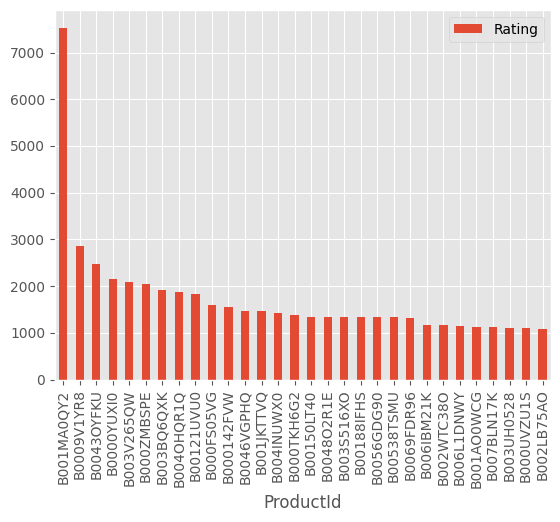

In [16]:
most_popular.head(30).plot(kind = "bar")

## Recommendation System - Part II

### Model-based collaborative filtering system

Recommend items to users based on purchase history and similarity of ratings provided by other users who bought items to that of a particular customer.

A model based collaborative filtering technique is closen here as it helps in making predictinfg products for a particular user by identifying patterns based on preferences from multiple user data.

#### Utility Matrix based on products sold and user reviews

Utility Matrix

An utlity matrix is consists of all possible user-item preferences (ratings) details represented as a matrix. The utility matrix is sparce as none of the users would buy all teh items in the list, hence, most of the values are unknown.

In [17]:
# Subset of Amazon Ratings

amazon_ratings1 = amazon_ratings.head(10000)

In [18]:
ratings_utility_matrix = amazon_ratings1.pivot_table(values='Rating', index='UserId', columns='ProductId', fill_value=0)
ratings_utility_matrix.head()

ProductId,0205616461,0558925278,0733001998,0737104473,0762451459,1304139212,1304139220,130414089X,130414643X,1304146537,...,B000052YPE,B000052YPF,B000052YPG,B000052YPH,B000052YPM,B000052YPU,B000052YPV,B000052YPY,B000052YQ0,B000052YQ2
UserId,,,,,,,,,,,,,,,,,,,,,
A00205921JHJK5X9LNP42,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A024581134CV80ZBLIZTZ,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A03056581JJIOL5FSKJY7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A03099101ZRK4K607JVHH,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
A0505229A7NSH3FRXRR4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


As expected, the utility matrix obtaned above is sparce, I have filled up the unknown values wth 0.

In [19]:
ratings_utility_matrix.shape

(9697, 886)

Transposing the matrix

In [20]:
X = ratings_utility_matrix.T
X.head()

UserId,A00205921JHJK5X9LNP42,A024581134CV80ZBLIZTZ,A03056581JJIOL5FSKJY7,A03099101ZRK4K607JVHH,A0505229A7NSH3FRXRR4,A05492663T95KW63BR75K,A059547920Q3LZVFHLPI3,A07410232KYRFR25CIUGJ,A082796624UNM47DSAI6K,A0864963DOAY7LXGS5I6,...,AZW1HXXYAC15B,AZWRTJPN7NXT,AZWTXHXZXFAYP,AZYQEFB9Y5N22,AZZHB6U54UDYW,AZZHJZP4GQPPZ,AZZNK89PXD006,AZZOFVMQC0BJG,AZZQXL8VDCFTV,AZZTJQ7CQZUD8
ProductId,,,,,,,,,,,,,,,,,,,,,
0205616461,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0558925278,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0733001998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0737104473,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
0762451459,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
X.shape

(886, 9697)

Unique products in subset of data

In [23]:
X1 = X

### Decomposing the Matrix

In [24]:
SVD = TruncatedSVD(n_components=10)
decomposed_matrix = SVD.fit_transform(X)
decomposed_matrix.shape

(886, 10)

### Correlation Matrix

In [25]:
correlation_matrix = np.corrcoef(decomposed_matrix)
correlation_matrix.shape

(886, 886)

correlation_matrix

In [26]:
X.index[99]

'6117036094'

Index # of product ID purchased by customer

In [27]:
i = "6117036094"

product_names = list(X.index)
product_ID = product_names.index(i)
product_ID

99

Correlation for all items with the item purchased by this customer based on items rated by other customers people who bought the same product

In [28]:
correlation_product_ID = correlation_matrix[product_ID]
correlation_product_ID.shape

(886,)

### Recommending top 10 highly correlated products in sequence

In [29]:
Recommend = list(X.index[correlation_product_ID > 0.90])

# Removes the item already bought by the customer
Recommend.remove(i)

Recommend[0:9]

['0733001998',
 '1304511073',
 '1304511081',
 '1304622223',
 '1304622460',
 '1304624544',
 '9740200133',
 '9747842297',
 '978807801X']

Product Id #

Here are the top 10 products to be displayed by the recommendation system to the above customer based on the purchase history of other customers in the website.

## Recommendation System - Part III

For a business without any user-item purchase history, a search engine based recommendation system can be designed for users. The product recommendations can be based on textual clustering analysis given in product description.

In [30]:
# Importing libraries

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

## Home Depot's dataset with product dataset:

https://www.kaggle.com/c/home-depot-product-search-relevance/data

### Item to item based recommendation system based on product description

Applicable when business is setting up its E-commerce website for the first time

In [ ]:
import os
import zipfile

# Download dataset (requires Kaggle API and competition acceptance)
!kaggle competitions download -c home-depot-product-search-relevance

# Cross-platform unzip
zip_file = 'home-depot-product-search-relevance.zip'
if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('content/')
    print(f"Extracted {zip_file} successfully")
else:
    print(f"Note: {zip_file} not found. Ensure product_descriptions.csv exists in content/ folder.")

In [37]:
product_descriptions = pd.read_csv('content/product_descriptions.csv')
product_descriptions.shape

(124428, 2)

#### Checking for missing values

In [38]:
# Missing values

product_descriptions = product_descriptions.dropna()
product_descriptions.shape
product_descriptions.head()

,product_uid,product_description
0,100001,"Not only do angles make joints stronger, they ..."
1,100002,BEHR Premium Textured DECKOVER is an innovativ...
2,100003,Classic architecture meets contemporary design...
3,100004,The Grape Solar 265-Watt Polycrystalline PV So...
4,100005,Update your bathroom with the Delta Vero Singl...


In [39]:
product_descriptions1 = product_descriptions.head(500)
# product_descriptions1.iloc[:,1]

product_descriptions1["product_description"].head(10)

0    Not only do angles make joints stronger, they ...
1    BEHR Premium Textured DECKOVER is an innovativ...
2    Classic architecture meets contemporary design...
3    The Grape Solar 265-Watt Polycrystalline PV So...
4    Update your bathroom with the Delta Vero Singl...
5    Achieving delicious results is almost effortle...
6    The Quantum Adjustable 2-Light LED Black Emerg...
7    The Teks #10 x 1-1/2 in. Zinc-Plated Steel Was...
8    Get the House of Fara 3/4 in. x 3 in. x 8 ft. ...
9    Valley View Industries Metal Stakes (4-Pack) a...
Name: product_description, dtype: object

#### Feature extraction from product descriptions

Converting the text in product description into numerical data for analysis

In [40]:
vectorizer = TfidfVectorizer(stop_words='english')
X1 = vectorizer.fit_transform(product_descriptions1["product_description"])
X1

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 34817 stored elements and shape (500, 8932)>

#### Visualizing product clusters in subset of data

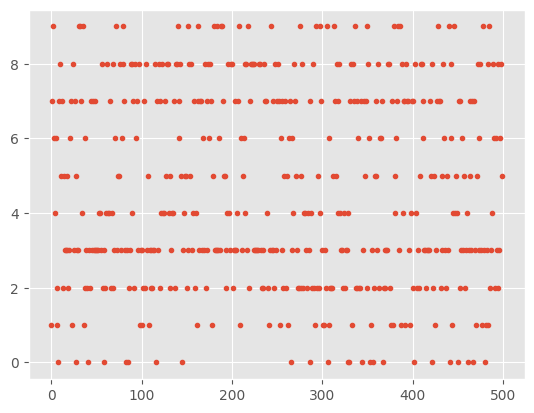

In [41]:
# Fitting K-Means to the dataset

X=X1

kmeans = KMeans(n_clusters = 10, init = 'k-means++')
y_kmeans = kmeans.fit_predict(X)
plt.plot(y_kmeans, ".")
plt.show()


#### Top words in each cluster based on product description

In [42]:
# # Optimal clusters is

true_k = 10

model = KMeans(n_clusters=true_k, init='k-means++', max_iter=100, n_init=1)
model.fit(X1)

print("Top terms per cluster:")
order_centroids = model.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()
for i in range(true_k):
    print("Cluster %d:" % i),
    for ind in order_centroids[i, :10]:
        print(' %s' % terms[ind]),
    print

Top terms per cluster:
Cluster 0:
 window
 aluminum
 frame
 door
 cut
 screen
 easy
 roller
 home
 size
Cluster 1:
 light
 watt
 volt
 led
 power
 bulb
 fan
 bulbs
 lighting
 fixture
Cluster 2:
 watering
 gal
 offers
 water
 flush
 toilet
 design
 20
 tree
 spray
Cluster 3:
 cooking
 oven
 cycle
 cu
 wash
 insulation
 steam
 options
 large
 drawer
Cluster 4:
 water
 air
 use
 heater
 easy
 cooling
 ft
 valve
 filter
 temperature
Cluster 5:
 wall
 piece
 white
 finish
 toilet
 tile
 vanity
 look
 color
 bowl
Cluster 6:
 tool
 cutting
 metal
 paint
 easy
 handle
 blade
 grip
 brush
 power
Cluster 7:
 patio
 outdoor
 frame
 dining
 fabric
 cushions
 wicker
 steel
 chairs
 collection
Cluster 8:
 door
 proposition
 nbsp
 residents
 california
 65
 easy
 wood
 design
 installation
Cluster 9:
 post
 steel
 ft
 fence
 used
 lbs
 stake
 help
 rail
 storage


#### Predicting clusters based on key search words

cutting tool

In [43]:
print("Cluster ID:")
Y = vectorizer.transform(["cutting tool"])
prediction = model.predict(Y)
print(prediction)

Cluster ID:
[6]


spray paint

In [44]:
print("Cluster ID:")
Y = vectorizer.transform(["spray paint"])
prediction = model.predict(Y)
print(prediction)

Cluster ID:
[6]


steel drill

In [45]:
print("Cluster ID:")
Y = vectorizer.transform(["steel drill"])
prediction = model.predict(Y)
print(prediction)

Cluster ID:
[9]


In case a word appears in multiple clusters, the algorithm chooses the cluster with the highest frequency of occurance of the word.

water

In [46]:
print("Cluster ID:")
Y = vectorizer.transform(["water"])
prediction = model.predict(Y)
print(prediction)

Cluster ID:
[4]


In [47]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import numpy as np

# Sample Arabic text data (replace with your actual data)
arabic_texts = [
    "هذا النص الأول باللغة العربية عن التعلم الآلي",
    "النص الثاني يتحدث عن معالجة اللغات الطبيعية",
    "تطبيقات التعلم الآلي في تحليل النصوص العربية",
    "معالجة اللغات الطبيعية وأهميتها في فهم النص",
    "تحليل النص باستخدام تقنيات التعلم الآلي ومعالجة اللغات الطبيعية"
]

# A more comprehensive list of Arabic stop words
# Source: https://github.com/stopwords-iso/stopwords-ar/blob/master/stopwords-ar.txt
arabic_stop_words = [
    "ء", "آ", "أ", "ؤ", "إ", "ئ", "ا", "ب", "ت", "ث", "ج", "ح", "خ", "د", "ذ", "ر", "ز", "س", "ش", "ص", "ض", "ط", "ظ", "ع",
    "غ", "ف", "ق", "ك", "ل", "م", "ن", "ه", "و", "ي", "ة", "ى", "ألف", "أما", "أما", "أي", "أين", "أينما", "أولئك", "أولاء",
    "أولاء", "أولالك", "آن", "آناء", "آه", "بخ", "بس", "بعد", "بعض", "بكلا", "بكلتا", "بين", "بينما", "تلك", "تلكم",
    "تيه", "ثمة", "جلل", "جمع", "جميع", "حاشا", "حتى", "حيث", "حيثما", "حيص", "حين", "خلا", "دون", "ذا", "ذات", "ذي",
    "ذيت", "ذين", "سات", "سوف", "سي", "شتان", "ص", "صبح", "صه", "صور", "ضد", "ضل", "طالما", "عام", "عما", "عن", "عند",
    "عندما", "عين", "ف", "فوق", "في", "فينما", "قد", "قدس", "قط", "قبل", "قليل", "كأن", "كأي", "كذا", "كذلك", "كل", "كلا",
    "كلتا", "كلم", "كي", "كيف", "كيفما", "لعل", "لك", "لكم", "لما", "لماذا", "لن", "لو", "لولا", "لوما", "ليت", "ليس",
    "ما", "ماذا", "متى", "مثل", "مع", "مما", "ممن", "من", "منذ", "منها", "مه", "مهما", "نحن", "نحو", "نعم", "هأن", "هاتا",
    "هاته", "هاهنا", "هذا", "هذان", "هذه", "هذي", "هؤلاء", "هاتان", "هكذا", "هل", "هلا", "هم", "هما", "هن", "هو", "هي",
    "هيا", "هيت", "هيهات", "و", "ولكن", "يا", "ي", "كأيّ", "أيّا", "حيثُ", "إذما", "منذُ", "إذا", "أنّى", "أيّان", "بما",
    "الآن", "بمن", "عمن", "فيما", "فيم", "كلمّا", "مهما", "عنْدَ", "أَصبح", "أَمْسَي", "أَوْ", "أَمس", "كَذا", "لَيْتَ",
    "لَعَلَّ", "مَازَال", "ماانْفَكّ", "مافَتِئ", "ماكار", "ماكد", "وَأَنا", "ذا", "ذَات", "ذَوات", "ذَوي", "ذَوّا", "ذَا",
    "ذِي", "الَّذي", "التي", "اللذان", "اللتان", "الذين", "اللاتي", "اللاء", "اللواتي", "إلّا", "مَن", "بِمَن", "عَمَّن",
    "فِيمَن", "ليست"
]


# Initialize TfidfVectorizer with Arabic stop words
# You may need to experiment with the 'tokenizer' parameter for better results
vectorizer_ar = TfidfVectorizer(stop_words=arabic_stop_words)

# Fit and transform the Arabic texts
X_arabic = vectorizer_ar.fit_transform(arabic_texts)

print("Shape of the vectorized Arabic data:", X_arabic.shape)

# Apply K-Means clustering (example with 2 clusters)
true_k_ar = 2 # You can adjust the number of clusters
model_ar = KMeans(n_clusters=true_k_ar, init='k-means++', max_iter=100, n_init=10)
model_ar.fit(X_arabic)

print("\nTop terms per cluster:")
order_centroids_ar = model_ar.cluster_centers_.argsort()[:, ::-1]
terms_ar = vectorizer_ar.get_feature_names_out()

for i in range(true_k_ar):
    print("Cluster %d:" % i),
    for ind in order_centroids_ar[i, :10]:
        print(' %s' % terms_ar[ind]),
    print

# Predict the cluster for a new Arabic text
new_arabic_text = ["تطبيقات التعلم الآلي"]
Y_arabic = vectorizer_ar.transform(new_arabic_text)
prediction_ar = model_ar.predict(Y_arabic)
print("\nCluster ID for the new text:", prediction_ar)

Shape of the vectorized Arabic data: (5, 19)

Top terms per cluster:
Cluster 0:
 معالجة
 اللغات
 الطبيعية
 النص
 الثاني
 يتحدث
 وأهميتها
 فهم
 ومعالجة
 تقنيات
Cluster 1:
 التعلم
 الآلي
 العربية
 تحليل
 النص
 الأول
 باللغة
 النصوص
 تطبيقات
 ومعالجة

Cluster ID for the new text: [1]


d:\private\Coding\Aliaa Graduation Project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['أن', 'إل', 'ات', 'از', 'ال', 'ان', 'ماان', 'ماف', 'مس', 'نا', 'وات', 'وي', 'يم'] not in stop_words.
  warnings.warn(


### Popularity-Based Recommendation System for Arabic Data

#### Loading the Arabic dataset

In [ ]:
import os
import zipfile

# Download Arabic company reviews dataset
!kaggle datasets download -d fahdseddik/arabic-company-reviews

# Cross-platform unzip
zip_file = 'arabic-company-reviews.zip'
if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall('content/')
    print(f"Extracted {zip_file} to content/ folder")
else:
    print(f"Note: {zip_file} not found. Ensure CompanyReviews.csv exists in content/ folder.")

In [53]:
import pandas as pd

# Replace 'your_arabic_ratings_data.csv' with the actual path to your Arabic data file
try:
    arabic_ratings = pd.read_csv('content/CompanyReviews.csv')
    # Handle missing values if necessary
    arabic_ratings = arabic_ratings.dropna()
    print("Arabic dataset loaded successfully.")
    print(arabic_ratings.head())
except FileNotFoundError:
    print("Error: 'your_arabic_ratings_data.csv' not found. Please replace with the correct file path.")
    # Create a dummy DataFrame for demonstration if the file is not found
    arabic_ratings = pd.DataFrame({
        'UserId': ['user1', 'user2', 'user3', 'user1', 'user2'],
        'ProductId': ['منتج_أ', 'منتج_ب', 'منتج_أ', 'منتج_ج', 'منتج_ب'],
        'Rating': [5, 4, 5, 3, 4],
        'Timestamp': [1, 2, 3, 4, 5]
    })
    print("\nUsing dummy data for demonstration:")
    print(arabic_ratings.head())

Arabic dataset loaded successfully.
   Unnamed: 0                                 review_description  rating  \
0           0                                               رائع       1   
1           1  برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...       1   
2           2  التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...      -1   
3           3                 لماذا لا يمكننا طلب من ماكدونالدز؟      -1   
4           4  البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...      -1   

  company  
0  talbat  
1  talbat  
2  talbat  
3  talbat  
4  talbat  


#### Calculating Popularity

In [55]:
if not arabic_ratings.empty:
    arabic_popular_products = pd.DataFrame(arabic_ratings.groupby('company')['rating'].count())
    arabic_most_popular = arabic_popular_products.sort_values('rating', ascending=False)

    print("\nTop 10 most popular Arabic companies based on rating count:")
    display(arabic_most_popular.head(10))
else:
    print("\nCannot calculate popularity as the Arabic dataset is empty.")


Top 10 most popular Arabic companies based on rating count:


,rating
company,
talbat,32072
swvl,4693
telecom_egypt,2090
venus,281
Raya,268
TMG,250
elsewedy,147
hilton,100
capiter,73


In [56]:
print(arabic_ratings.columns)

Index(['Unnamed: 0', 'review_description', 'rating', 'company'], dtype='object')


### Model-based collaborative filtering system for Arabic Data

#### Utility Matrix based on companies and user ratings

In [57]:
# Create the utility matrix for Arabic data
arabic_ratings_utility_matrix = arabic_ratings.pivot_table(values='rating', index='Unnamed: 0', columns='company', fill_value=0)
print("\nArabic Ratings Utility Matrix:")
display(arabic_ratings_utility_matrix.head())


Arabic Ratings Utility Matrix:


company,Ezz Steel,Raya,TMG,capiter,domty,elsewedy,hilton,nestle,swvl,talbat,telecom_egypt,venus
Unnamed: 0,,,,,,,,,,,,
0,0.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0
1,-1.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,1.0,0.0,0.0
2,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
3,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0
4,-1.0,0.0,-1.0,1.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0,0.0


Transposing the matrix

In [58]:
X_arabic_cf = arabic_ratings_utility_matrix.T
print("\nTransposed Arabic Utility Matrix:")
display(X_arabic_cf.head())
print("\nShape of Transposed Arabic Utility Matrix:", X_arabic_cf.shape)


Transposed Arabic Utility Matrix:


Unnamed: 0,0,1,2,3,4,5,6,7,8,9,...,39531,39532,39533,39534,39535,39536,39537,39538,39539,39540
company,,,,,,,,,,,,,,,,,,,,,
Ezz Steel,0.0,-1.0,1.0,-1.0,-1.0,1.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Raya,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
TMG,-1.0,1.0,1.0,-1.0,-1.0,1.0,-1.0,1.0,1.0,-1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
capiter,1.0,-1.0,1.0,-1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
domty,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0



Shape of Transposed Arabic Utility Matrix: (12, 39540)


### Decomposing the Matrix (Arabic Data)

In [59]:
from sklearn.decomposition import TruncatedSVD

# Apply SVD to the transposed matrix
SVD_arabic = TruncatedSVD(n_components=10) # You can adjust the number of components
decomposed_matrix_arabic = SVD_arabic.fit_transform(X_arabic_cf)
print("\nShape of Decomposed Arabic Matrix:", decomposed_matrix_arabic.shape)


Shape of Decomposed Arabic Matrix: (12, 10)


### Correlation Matrix (Arabic Data)

In [60]:
import numpy as np

# Calculate the correlation matrix
correlation_matrix_arabic = np.corrcoef(decomposed_matrix_arabic)
print("\nShape of Arabic Correlation Matrix:", correlation_matrix_arabic.shape) # Typo fixed here


Shape of Arabic Correlation Matrix: (12, 12)


### Recommending companies based on correlation (Arabic Data)

Assuming a customer interacts with a specific company (e.g., 'talbat')

In [ ]:
# Improved recommendation with adaptive threshold
company_of_interest = 'talbat'

# Get the index of the company of interest
company_names_arabic = list(X_arabic_cf.index)
try:
    company_ID_arabic = company_names_arabic.index(company_of_interest)
    print(f"\nIndex of '{company_of_interest}': {company_ID_arabic}")

    # Get the correlation for all companies with the company of interest
    correlation_company_ID_arabic = correlation_matrix_arabic[company_ID_arabic]
    
    # Show all correlations for debugging
    print(f"\nCorrelations with '{company_of_interest}':")
    for i, (company, corr) in enumerate(zip(company_names_arabic, correlation_company_ID_arabic)):
        print(f"  {company}: {corr:.4f}")
    
    # Use adaptive threshold: top N companies by correlation (excluding self)
    # Sort by correlation descending
    sorted_indices = np.argsort(correlation_company_ID_arabic)[::-1]
    
    # Get top N recommendations (excluding the company itself)
    top_n = 5
    Recommend_arabic = []
    for idx in sorted_indices:
        if company_names_arabic[idx] != company_of_interest:
            Recommend_arabic.append({
                'company': company_names_arabic[idx],
                'correlation': correlation_company_ID_arabic[idx]
            })
        if len(Recommend_arabic) >= top_n:
            break

    print(f"\nTop {top_n} recommended companies based on interaction with '{company_of_interest}':")
    for rec in Recommend_arabic:
        print(f"  {rec['company']}: correlation = {rec['correlation']:.4f}")
        
except ValueError:
    print(f"\nCompany '{company_of_interest}' not found in the dataset.")

### Offline Evaluation for Collaborative Filtering (Arabic Data)

#### Splitting the data into training and testing sets

In [62]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
train_data, test_data = train_test_split(arabic_ratings, test_size=0.2, random_state=42)

print("Shape of training data:", train_data.shape)
print("Shape of testing data:", test_data.shape)

Shape of training data: (32036, 4)
Shape of testing data: (8009, 4)


#### Building the utility matrix and SVD model on the training data

In [63]:
# Create the utility matrix for the training data
train_data_utility_matrix = train_data.pivot_table(values='rating', index='Unnamed: 0', columns='company', fill_value=0)

# Transpose the matrix
X_train_cf = train_data_utility_matrix.T

# Apply SVD
SVD_train = TruncatedSVD(n_components=10) # Using the same number of components as before
decomposed_matrix_train = SVD_train.fit_transform(X_train_cf)

# Calculate the correlation matrix
correlation_matrix_train = np.corrcoef(decomposed_matrix_train)

print("Shape of training utility matrix:", train_data_utility_matrix.shape)
print("Shape of transposed training matrix:", X_train_cf.shape)
print("Shape of decomposed training matrix:", decomposed_matrix_train.shape)
print("Shape of training correlation matrix:", correlation_matrix_train.shape)

Shape of training utility matrix: (31687, 12)
Shape of transposed training matrix: (12, 31687)
Shape of decomposed training matrix: (12, 10)
Shape of training correlation matrix: (12, 12)


#### Evaluating the model on the testing data (Predicting ratings and calculating RMSE)

In [64]:
from sklearn.metrics import mean_squared_error

# Create a utility matrix for the test data (only for existing user-item pairs in test set)
# We need to make sure the columns (companies) are in the same order as the training matrix
test_data_utility_matrix = test_data.pivot_table(values='rating', index='Unnamed: 0', columns='company', fill_value=0).reindex(columns=train_data_utility_matrix.columns, fill_value=0)


# Get the list of companies from the training matrix
train_companies = list(train_data_utility_matrix.columns)

# Function to predict rating for a user-company pair
def predict_rating(user_id, company_name, train_utility_matrix, svd_model, train_companies, correlation_matrix):
    try:
        # Get the user's index in the training utility matrix
        user_index = list(train_utility_matrix.index).index(user_id)

        # Get the company's index in the training matrix
        try:
            company_index = train_companies.index(company_name)
        except ValueError:
            # If the company is not in the training data, we cannot make a prediction
            return None

        # Get the correlation values for the company from the training correlation matrix
        company_correlation = correlation_matrix[company_index]

        # Get the ratings of the user from the training utility matrix
        user_ratings = train_utility_matrix.loc[user_id].values

        # Calculate predicted rating using a weighted sum of correlations and user ratings
        # Only consider items the user has rated and that have a positive correlation
        numerator = np.sum(company_correlation * user_ratings)
        denominator = np.sum(np.abs(company_correlation)) # Using absolute values of correlations as weights

        if denominator == 0:
            return train_utility_matrix[company_name].mean() # Fallback to average rating if no correlated items

        predicted_rating = numerator / denominator
        return predicted_rating

    except ValueError:
        # If the user is not in the training data, we cannot make a prediction
        return None


# Prepare data for RMSE calculation
actual_ratings = []
predicted_ratings = []

# Iterate through the test data and make predictions
for index, row in test_data.iterrows():
    user_id = row['Unnamed: 0'] # Using 'Unnamed: 0' as user identifier
    company_name = row['company']
    actual_rating = row['rating']

    predicted_rating = predict_rating(user_id, company_name, train_data_utility_matrix, SVD_train, train_companies, correlation_matrix_train)

    # Only include pairs where a prediction could be made
    if predicted_rating is not None:
        actual_ratings.append(actual_rating)
        predicted_ratings.append(predicted_rating)

# Calculate RMSE
if actual_ratings and predicted_ratings:
    rmse = np.sqrt(mean_squared_error(actual_ratings, predicted_ratings))
    print(f"\nRMSE on the test set: {rmse}")
else:
    print("\nCould not make any predictions on the test set with the current model and data.")


RMSE on the test set: 0.957387306154669


In [ ]:
# Comprehensive Evaluation Metrics for Recommendation Systems
import numpy as np
from sklearn.metrics import mean_squared_error

def precision_at_k(actual, predicted, k):
    """
    Calculate Precision@K: proportion of recommended items that are relevant.
    
    Args:
        actual: List of actual relevant items for a user
        predicted: List of recommended items (ranked)
        k: Number of recommendations to consider
    """
    if len(predicted) > k:
        predicted = predicted[:k]
    
    if not actual or not predicted:
        return 0.0
    
    relevant_count = len(set(predicted) & set(actual))
    return relevant_count / len(predicted)

def recall_at_k(actual, predicted, k):
    """
    Calculate Recall@K: proportion of relevant items that are recommended.
    
    Args:
        actual: List of actual relevant items for a user
        predicted: List of recommended items (ranked)
        k: Number of recommendations to consider
    """
    if len(predicted) > k:
        predicted = predicted[:k]
    
    if not actual:
        return 0.0
    
    relevant_count = len(set(predicted) & set(actual))
    return relevant_count / len(actual)

def dcg_at_k(relevances, k):
    """Calculate Discounted Cumulative Gain at K."""
    relevances = np.asarray(relevances)[:k]
    if relevances.size:
        return np.sum(relevances / np.log2(np.arange(2, relevances.size + 2)))
    return 0.0

def ndcg_at_k(actual, predicted, k):
    """
    Calculate Normalized Discounted Cumulative Gain at K.
    
    Args:
        actual: List of actual relevant items
        predicted: List of recommended items (ranked)
        k: Number of recommendations to consider
    """
    if len(predicted) > k:
        predicted = predicted[:k]
    
    # Binary relevance: 1 if item is relevant, 0 otherwise
    relevances = [1 if item in actual else 0 for item in predicted]
    
    dcg = dcg_at_k(relevances, k)
    
    # Ideal DCG: all relevant items at top
    ideal_relevances = sorted(relevances, reverse=True)
    idcg = dcg_at_k(ideal_relevances, k)
    
    if idcg == 0:
        return 0.0
    return dcg / idcg

def mean_average_precision(actual_list, predicted_list, k):
    """
    Calculate Mean Average Precision across all users.
    """
    aps = []
    for actual, predicted in zip(actual_list, predicted_list):
        if not actual:
            continue
        
        # Calculate AP for this user
        relevant_count = 0
        precision_sum = 0
        
        for i, item in enumerate(predicted[:k]):
            if item in actual:
                relevant_count += 1
                precision_sum += relevant_count / (i + 1)
        
        if relevant_count > 0:
            aps.append(precision_sum / min(len(actual), k))
    
    return np.mean(aps) if aps else 0.0

# Evaluate the recommendation system with multiple metrics
def evaluate_recommendations(train_data, test_data, correlation_matrix, train_companies, k=5):
    """
    Comprehensive evaluation of recommendation system.
    """
    # Group test data by user to get their actual interactions
    test_user_items = test_data.groupby('Unnamed: 0')['company'].apply(list).to_dict()
    train_user_items = train_data.groupby('Unnamed: 0')['company'].apply(list).to_dict()
    
    precision_scores = []
    recall_scores = []
    ndcg_scores = []
    
    # Get recommendations for each user
    for user_id, actual_items in test_user_items.items():
        if user_id not in train_user_items:
            continue
            
        # Get user's training items to generate recommendations
        user_train_items = train_user_items.get(user_id, [])
        
        if not user_train_items:
            continue
        
        # Generate recommendations based on items user interacted with
        recommendations = set()
        for item in user_train_items:
            if item in train_companies:
                item_idx = train_companies.index(item)
                item_corrs = correlation_matrix[item_idx]
                
                # Get top correlated items
                top_indices = np.argsort(item_corrs)[::-1][:k+1]
                for idx in top_indices:
                    if train_companies[idx] != item:
                        recommendations.add(train_companies[idx])
        
        predicted = list(recommendations)[:k]
        
        if not predicted:
            continue
        
        # Calculate metrics
        precision_scores.append(precision_at_k(actual_items, predicted, k))
        recall_scores.append(recall_at_k(actual_items, predicted, k))
        ndcg_scores.append(ndcg_at_k(actual_items, predicted, k))
    
    return {
        'Precision@K': np.mean(precision_scores) if precision_scores else 0.0,
        'Recall@K': np.mean(recall_scores) if recall_scores else 0.0,
        'NDCG@K': np.mean(ndcg_scores) if ndcg_scores else 0.0
    }

# Run comprehensive evaluation
print("=" * 50)
print("Comprehensive Recommendation System Evaluation")
print("=" * 50)

# First, the RMSE we already calculated
print(f"\n1. RMSE (Rating Prediction): {rmse:.4f}")

# Calculate ranking metrics
train_companies_list = list(train_data_utility_matrix.columns)
ranking_metrics = evaluate_recommendations(
    train_data, test_data, 
    correlation_matrix_train, train_companies_list, 
    k=5
)

print(f"\n2. Ranking Metrics (k=5):")
print(f"   Precision@5: {ranking_metrics['Precision@K']:.4f}")
print(f"   Recall@5: {ranking_metrics['Recall@K']:.4f}")
print(f"   NDCG@5: {ranking_metrics['NDCG@K']:.4f}")

# Coverage: what proportion of items can be recommended
recommended_items = set()
for company in train_companies_list:
    if company in train_companies_list:
        company_idx = train_companies_list.index(company)
        correlations = correlation_matrix_train[company_idx]
        for i, corr in enumerate(correlations):
            if corr > 0.1 and train_companies_list[i] != company:
                recommended_items.add(train_companies_list[i])

coverage = len(recommended_items) / len(train_companies_list) if train_companies_list else 0
print(f"\n3. Coverage: {coverage:.4f} ({len(recommended_items)}/{len(train_companies_list)} items)")

print("\n" + "=" * 50)

## Recommendation System - Part III (Arabic Data)

### Item to item based recommendation system based on review descriptions (Arabic Data)

#### Feature extraction from review descriptions (Arabic Data)

In [65]:
# Using the review_description column from the arabic_ratings DataFrame
arabic_descriptions = arabic_ratings['review_description'].dropna()

# Use the Arabic TfidfVectorizer with the comprehensive stop word list
# (Assuming arabic_stop_words and vectorizer_ar are already defined from previous steps in cell bPa7iD9xdDz5)
# If not, you would need to redefine them here:
# from sklearn.feature_extraction.text import TfidfVectorizer
# arabic_stop_words = [...] # Your comprehensive list
# vectorizer_ar = TfidfVectorizer(stop_words=arabic_stop_words)

X_arabic_text = vectorizer_ar.fit_transform(arabic_descriptions)

print("Shape of the vectorized Arabic review descriptions:", X_arabic_text.shape)

Shape of the vectorized Arabic review descriptions: (40045, 47572)


#### Visualizing review clusters in Arabic data

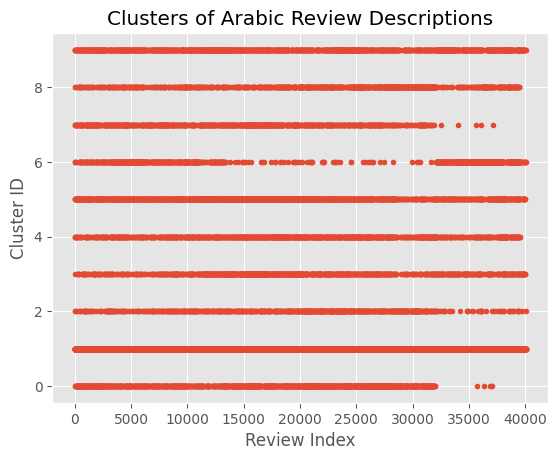

In [66]:
# Fitting K-Means to the dataset

X_for_clustering_ar = X_arabic_text

# Use the same number of clusters or choose a different one
true_k_ar_text = 10 # You can adjust the number of clusters
kmeans_ar_text = KMeans(n_clusters = true_k_ar_text, init = 'k-means++', n_init=10)
y_kmeans_ar_text = kmeans_ar_text.fit_predict(X_for_clustering_ar)
plt.plot(y_kmeans_ar_text, ".")
plt.title("Clusters of Arabic Review Descriptions")
plt.xlabel("Review Index")
plt.ylabel("Cluster ID")
plt.show()

#### Top words in each cluster based on review descriptions (Arabic Data)

In [67]:
# Print top terms per cluster

print("Top terms per cluster:")
order_centroids_ar_text = kmeans_ar_text.cluster_centers_.argsort()[:, ::-1]
terms_ar_text = vectorizer_ar.get_feature_names_out()

for i in range(true_k_ar_text):
    print(f"Cluster {i}:"),
    for ind in order_centroids_ar_text[i, :10]:
        print(' %s' % terms_ar_text[ind]),
    print

Top terms per cluster:
Cluster 0:
 الطلب
 جدا
 طلبت
 يوصل
 لا
 ولا
 المطعم
 تطبيق
 التطبيق
 يتأخر
Cluster 1:
 التطبيق
 لا
 جدا
 جميل
 على
 طلبات
 المطاعم
 انا
 الله
 جيد
Cluster 2:
 حلو
 مره
 وايد
 التطبيق
 والله
 برنامج
 البرنامج
 جدا
 مو
 كتير
Cluster 3:
 ممتاز
 جدا
 تطبيق
 شكرا
 التطبيق
 وسهل
 برنامج
 سهل
 وسريع
 جدآ
Cluster 4:
 برنامج
 رائع
 افضل
 جدا
 جميل
 ممتاز
 فاشل
 احسن
 طلبات
 سهل
Cluster 5:
 تطبيق
 رائع
 افضل
 جدا
 جميل
 احسن
 اكثر
 فاشل
 شكرا
 طلبات
Cluster 6:
 مش
 شغال
 راضي
 التطبيق
 عارف
 عايز
 انا
 ليه
 يفتح
 البرنامج
Cluster 7:
 التوصيل
 جدا
 سعر
 سريع
 ممتاز
 اسعار
 المطاعم
 خدمة
 التطبيق
 تطبيق
Cluster 8:
 البرنامج
 جدا
 لا
 على
 رائع
 جميل
 حلو
 ممتاز
 انا
 روعه
Cluster 9:
 جدا
 جميل
 رائع
 جيد
 تطبيق
 ممتاز
 سيء
 التطبيق
 سئ
 ممتازه


#### Predicting clusters based on key search words (Arabic Data)

Example search: خدمة عملاء ممتازة (Excellent customer service)

In [68]:
print("Cluster ID for 'خدمة عملاء ممتازة':")
search_text_ar = ["خدمة عملاء ممتازة"]
Y_search_ar = vectorizer_ar.transform(search_text_ar)
prediction_search_ar = kmeans_ar_text.predict(Y_search_ar)
print(prediction_search_ar)

# Find similar reviews in the predicted cluster
# You might want to implement a function to find nearest neighbors in the cluster

Cluster ID for 'خدمة عملاء ممتازة':
[1]


In [69]:
!pip install kneed

Arabic Dataset (CompanyReviews.csv) Preview:
   Unnamed: 0                                 review_description  rating  \
0           0                                               رائع       1   
1           1  برنامج رائع جدا يساعد على تلبيه الاحتياجات بشك...       1   
2           2  التطبيق لا يغتح دائما بيعطيني لا يوجد اتصال با...      -1   
3           3                 لماذا لا يمكننا طلب من ماكدونالدز؟      -1   
4           4  البرنامج بيظهر كل المطاعم و مغلقه مع انها بتكو...      -1   

  company  
0  talbat  
1  talbat  
2  talbat  
3  talbat  
4  talbat  

Top 10 Most Popular Companies:
               rating
company              
talbat          32072
swvl             4693
telecom_egypt    2090
venus             281
Raya              268
TMG               250
elsewedy          147
hilton            100
capiter            73
Ezz Steel          49

Top Recommendations for 'talbat' (Collaborative Filtering):
[]

Top Terms per Cluster:
Cluster 0:
  جميل
  جدا
  تطبيق
  برنامج
 

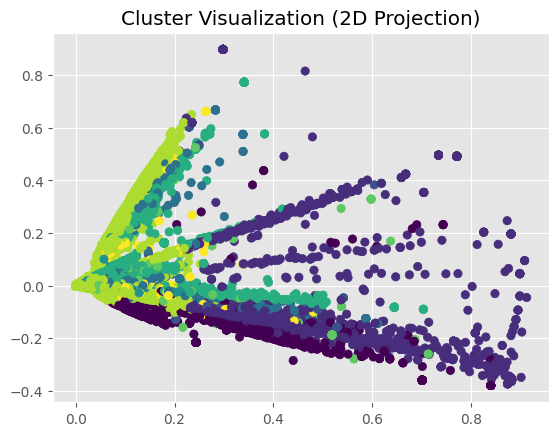


Predicted Cluster for 'خدمة عملاء ممتازة': 3

Collaborative Filtering Evaluation:
RMSE: 0.9397
Precision@5: 0.0000
Silhouette Score for Content-Based Clustering: 0.0486


In [70]:
import numpy as np
import pandas as pd
import re
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, silhouette_score
import matplotlib.pyplot as plt
from kneed import KneeLocator

# --- Arabic Text Preprocessing ---
def preprocess_arabic_text(text):
    """Normalize Arabic text: remove diacritics, tatweel, and extra spaces."""
    # Remove diacritics (harakat)
    text = re.sub(r'[\u0617-\u061A\u064B-\u065F]', '', text)
    # Remove tatweel
    text = re.sub(r'\u0640', '', text)
    # Normalize spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Comprehensive Arabic stop words (partial list, expand as needed)
arabic_stop_words = [
    'و', 'في', 'على', 'من', 'إلى', 'هذا', 'هذه', 'الذي', 'التي', 'ب', 'عن',
    'ك', 'ل', 'أن', 'ما', 'هو', 'هي', 'كان', 'كانت', 'لم', 'لا'
]

# --- Load and Preprocess Data ---
# The data is already loaded into arabic_ratings from '/content/CompanyReviews.csv'
# in a previous cell. We will use this DataFrame.

# Handle missing values if necessary (already done during loading, but good to be explicit)
arabic_ratings = arabic_ratings.dropna()
arabic_ratings['review_description'] = arabic_ratings['review_description'].apply(preprocess_arabic_text)
print("Arabic Dataset (CompanyReviews.csv) Preview:")
print(arabic_ratings.head())

# --- Part I: Popularity-Based Recommendations ---
def get_popular_companies(df, top_n=10):
    """Return top N popular companies based on rating count."""
    popular_companies = pd.DataFrame(df.groupby('company')['rating'].count())
    return popular_companies.sort_values('rating', ascending=False).head(top_n)

print("\nTop 10 Most Popular Companies:")
print(get_popular_companies(arabic_ratings))

# --- Part II: Collaborative Filtering with SVD ---
def collaborative_filtering(df, company_of_interest, n_components=50, threshold=0.2, top_n=9):
    """Generate recommendations using SVD-based collaborative filtering."""
    try:
        # Using 'Unnamed: 0' as User ID and 'company' as Item ID
        # Ensure the index is unique for pivot_table, using 'Unnamed: 0'
        utility_matrix = df.pivot_table(values='rating', index='Unnamed: 0', columns='company', fill_value=0)
        X = utility_matrix.T
        n_components = min(n_components, X.shape[0], X.shape[1] - 1)
        if n_components < 1:
            return [], "Matrix too small for SVD."

        svd = TruncatedSVD(n_components=n_components, random_state=42)
        decomposed_matrix = svd.fit_transform(X)
        correlation_matrix = np.corrcoef(decomposed_matrix)

        company_names = list(X.index)
        if company_of_interest not in company_names:
            return [], f"Company '{company_of_interest}' not found."

        company_idx = company_names.index(company_of_interest)
        correlations = correlation_matrix[company_idx]
        recommendations = list(X.index[correlations > threshold])
        if company_of_interest in recommendations:
            recommendations.remove(company_of_interest)
        return recommendations[:top_n], None
    except Exception as e:
        return [], f"Error in collaborative filtering: {str(e)}"

company_of_interest = 'talbat'
recommendations, error = collaborative_filtering(arabic_ratings, company_of_interest)
if error:
    print(f"\n{error}")
else:
    print(f"\nTop Recommendations for '{company_of_interest}' (Collaborative Filtering):")
    print(recommendations)

# --- Part III: Content-Based Recommendations with TF-IDF and KMeans ---
def find_optimal_clusters(X, max_k=15):
    """Use elbow method to find optimal number of clusters."""
    inertias = []
    K = range(2, max_k + 1)
    for k in K:
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)

    # Find elbow point
    knee = KneeLocator(K, inertias, curve='convex', direction='decreasing')
    return knee.elbow if knee.elbow else min(10, max_k)

def content_based_clustering(descriptions, search_term, max_k=15):
    """Perform content-based clustering and predict cluster for search term."""
    if descriptions.empty:
        return None, None, "No review descriptions available."

    # Initialize TF-IDF with Arabic stop words and limited vocabulary
    vectorizer = TfidfVectorizer(stop_words=arabic_stop_words, max_features=5000)
    X_text = vectorizer.fit_transform(descriptions)

    # Find optimal number of clusters
    n_clusters = find_optimal_clusters(X_text, max_k)
    if n_clusters < 2:
        return None, None, "Not enough data for clustering."

    # Apply KMeans
    kmeans = KMeans(n_clusters=n_clusters, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_text)

    # Get top terms per cluster
    terms = vectorizer.get_feature_names_out()
    order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]
    print("\nTop Terms per Cluster:")
    for i in range(n_clusters):
        print(f"Cluster {i}:")
        for ind in order_centroids[i, :10]:
            print(f"  {terms[ind]}")

    # Predict cluster for search term
    Y_search = vectorizer.transform([preprocess_arabic_text(search_term)])
    prediction = kmeans.predict(Y_search)

    # Visualize clusters (2D projection for demo)
    if X_text.shape[1] > 1:
        svd_2d = TruncatedSVD(n_components=2, random_state=42)
        X_2d = svd_2d.fit_transform(X_text)
        plt.scatter(X_2d[:, 0], X_2d[:, 1], c=kmeans.labels_, cmap='viridis')
        plt.title("Cluster Visualization (2D Projection)")
        plt.show()

    return kmeans.labels_, X_text, None

search_term = "خدمة عملاء ممتازة"
labels, X_text, error = content_based_clustering(arabic_ratings['review_description'], search_term)
if error:
    print(f"\n{error}")
else:
    print(f"\nPredicted Cluster for '{search_term}': {labels[0]}")

# --- Evaluation ---
def evaluate_collaborative_filtering(df, n_components=10, k=5):
    """Evaluate collaborative filtering with RMSE and Precision@K."""
    if df.shape[0] < 10 or df['company'].nunique() < 2:
        return None, None, "Insufficient data for evaluation."

    train, test = train_test_split(df, test_size=0.2, random_state=42)
    utility_train = train.pivot_table(values='rating', index='Unnamed: 0', columns='company', fill_value=0).T
    n_components = min(n_components, utility_train.shape[0], utility_train.shape[1] - 1)
    if n_components < 1:
        return None, None, "Training matrix too small for SVD."

    svd = TruncatedSVD(n_components=n_components, random_state=42)
    decomposed_train = svd.fit_transform(utility_train)
    reconstructed = np.dot(decomposed_train, svd.components_)

    # Map predictions to test set
    test_ratings = []
    pred_ratings = []
    for _, row in test.iterrows():
        user_id, company = row['Unnamed: 0'], row['company']
        if company in utility_train.index:
            company_idx = list(utility_train.index).index(company)
            pred = reconstructed[company_idx].mean()  # Simplified prediction
            test_ratings.append(row['rating'])
            pred_ratings.append(pred)

    if not test_ratings:
        return None, None, "No valid test predictions."

    rmse = np.sqrt(mean_squared_error(test_ratings, pred_ratings))

    # Precision@K: Check if recommended companies are rated highly (e.g., >=4)
    precision = 0
    count = 0
    for company in utility_train.index[:k]:
        recs, _ = collaborative_filtering(train, company, n_components=n_components, top_n=k)
        actual_high = set(train[train['rating'] >= 4]['company'])
        recommended = set(recs)
        if recommended:
            precision += len(recommended & actual_high) / len(recommended)
            count += 1
    precision_at_k = precision / count if count > 0 else 0

    return rmse, precision_at_k, None

def evaluate_content_based(X, labels):
    """Evaluate content-based clustering with Silhouette Score."""
    if X.shape[0] <= 1 or len(np.unique(labels)) <= 1:
        return None, "Insufficient data or clusters for Silhouette Score."
    return silhouette_score(X, labels), None

# Run evaluations
rmse, precision_at_k, error = evaluate_collaborative_filtering(arabic_ratings)
if error:
    print(f"\n{error}")
else:
    print(f"\nCollaborative Filtering Evaluation:\nRMSE: {rmse:.4f}\nPrecision@5: {precision_at_k:.4f}")

if 'X_text' in locals() and 'labels' in locals():
    sil_score, error = evaluate_content_based(X_text, labels)
    if error:
        print(f"\n{error}")
    else:
        print(f"Silhouette Score for Content-Based Clustering: {sil_score:.4f}")
else:
    print("\nCannot evaluate content-based clustering: No valid clustering data.")